# Complete Guide to Active Learning

This notebook provides a comprehensive introduction to active learning using `incerto`.

**What you'll learn:**
- What active learning is and when to use it
- 8 acquisition functions for selecting informative samples
- 5 query strategies for batch selection
- Running active learning loops
- Comparing acquisition strategies
- Best practices for production

**Runtime:** ~3 min (MPS/CUDA), ~10 min (CPU)

**Prerequisites:** Basic PyTorch knowledge

## Setup

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Acquisition functions
# Query strategies
from incerto.active import (
    BadgeSampling,
    BALDAcquisition,
    CoreSetSelection,
    DiversitySampling,
    EntropyAcquisition,
    LeastConfidenceAcquisition,
    MarginAcquisition,
    RandomAcquisition,
    UncertaintySampling,
)
from incerto.utils import seed_everything

seed_everything(42)

# Device selection: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## Part 1: Understanding Active Learning

### What is Active Learning?

Active learning is a machine learning paradigm where the algorithm actively queries an oracle (human annotator) to label the most informative samples. This is crucial when:
- **Labeling is expensive** (medical imaging, expert annotations)
- **Data is abundant but labels are scarce**
- **You want to maximize performance with minimal labeled data**

### Key Concept: Acquisition Functions

The **acquisition function** scores unlabeled samples by their informativeness:

| Function | Key Idea | Best For |
|----------|----------|----------|
| **Random** | Baseline (random selection) | Comparison |
| **Entropy** | Highest predictive entropy | Multi-class |
| **Least Confidence** | Lowest max probability | General purpose |
| **Margin** | Smallest margin between top-2 classes | Decision boundaries |
| **BALD** | Maximizes mutual information | Bayesian models |
| **Variance Ratio** | Disagreement across MC samples | MC Dropout |
| **Mean STD** | Average std across predictions | MC Dropout |

### Experimental Setup

- **Dataset**: Fashion-MNIST (harder than MNIST, ~90% vs 99% accuracy)
- **Initial labeled set**: 100 samples (0.17% of training data)
- **Query budget**: 10 rounds x 50 samples = 500 labels
- **Goal**: Reach high accuracy with minimal labels

## Part 2: Load Data

We use **Fashion-MNIST** because it's harder than MNIST, making active learning more impactful.

In [2]:
# Load Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

full_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform)

# Create pool: initial labeled (100) + unlabeled (5000) + validation (rest)
n_initial = 100
n_pool = 5000

indices = np.random.permutation(len(full_train))
labeled_indices = indices[:n_initial].tolist()
pool_indices = indices[n_initial:n_initial + n_pool].tolist()
val_indices = indices[n_initial + n_pool:].tolist()

val_dataset = Subset(full_train, val_indices)

# Optimized data loaders
num_workers = min(4, os.cpu_count() or 0)
pin_memory = device.type == "cuda"
loader_kwargs = dict(num_workers=num_workers, pin_memory=pin_memory, persistent_workers=num_workers > 0)

val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, **loader_kwargs)

print(f"Initial labeled: {n_initial}")
print(f"Unlabeled pool: {n_pool}")
print(f"Validation: {len(val_indices)}")
print(f"Test: {len(test_dataset)}")
print(f"DataLoader: num_workers={num_workers}, pin_memory={pin_memory}")

Initial labeled: 100
Unlabeled pool: 5000
Validation: 54900
Test: 10000
DataLoader: num_workers=4, pin_memory=False


## Part 3: Define Model and Training

In [3]:
class ActiveNet(nn.Module):
    """CNN with dropout for MC-sampling based acquisition functions."""

    def __init__(self, dropout_rate=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.dropout1(x)
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = self.dropout2(x)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)


def train_model(model, train_loader, epochs=5, lr=0.001):
    """Train model for specified epochs."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(data), target)
            loss.backward()
            optimizer.step()


@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model accuracy."""
    model.eval()
    correct, total = 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        pred = model(data).argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
    return correct / total


print("Model and training functions defined!")

Model and training functions defined!


## Part 4: Active Learning Loop

The active learning loop:
1. Train model on current labeled set
2. Score unlabeled samples using acquisition function
3. Select top-k samples with highest scores
4. Add selected samples to labeled set
5. Repeat

In [4]:
def run_active_learning(
    strategy,
    initial_labeled,
    initial_pool,
    n_rounds=10,
    n_query=50,
    train_epochs=5,
):
    """
    Run active learning loop.
    
    Args:
        strategy: Query strategy (UncertaintySampling, DiversitySampling, etc.)
        initial_labeled: List of initially labeled indices
        initial_pool: List of unlabeled pool indices
        n_rounds: Number of AL rounds
        n_query: Samples to query per round
        train_epochs: Training epochs per round
    
    Returns:
        dict with labeled_sizes, val_accs, test_accs
    """
    labeled_idx = initial_labeled.copy()
    pool_idx = initial_pool.copy()

    results = {"labeled_sizes": [], "val_accs": [], "test_accs": []}

    for round_i in range(n_rounds):
        # Create data loader for current labeled set
        labeled_dataset = Subset(full_train, labeled_idx)
        train_loader = DataLoader(
            labeled_dataset, batch_size=64, shuffle=True, **loader_kwargs
        )

        # Train model
        model = ActiveNet().to(device)
        train_model(model, train_loader, epochs=train_epochs)

        # Evaluate
        val_acc = evaluate(model, val_loader)
        test_acc = evaluate(model, test_loader)

        results["labeled_sizes"].append(len(labeled_idx))
        results["val_accs"].append(val_acc)
        results["test_accs"].append(test_acc)

        print(f"  Round {round_i+1}/{n_rounds}: {len(labeled_idx):4d} labels, "
              f"val={val_acc*100:.1f}%, test={test_acc*100:.1f}%")

        # Query next batch (skip on last round)
        if round_i < n_rounds - 1 and len(pool_idx) > 0:
            # Get pool data as tensor
            pool_dataset = Subset(full_train, pool_idx)
            pool_data = torch.stack([pool_dataset[i][0] for i in range(len(pool_dataset))])
            pool_data = pool_data.to(device)

            # Query using strategy
            query_idx = strategy.query(model, pool_data)
            query_idx = query_idx.cpu().numpy()

            # Map to global indices and update sets
            queried_global = [pool_idx[i] for i in query_idx]
            labeled_idx.extend(queried_global)
            pool_idx = [idx for i, idx in enumerate(pool_idx) if i not in query_idx]

    return results


print("Active learning function defined!")

Active learning function defined!


## Part 5: Compare Acquisition Functions

We compare 5 acquisition functions using `UncertaintySampling` strategy:
- **Random**: Baseline
- **Entropy**: Highest predictive entropy
- **Least Confidence**: Lowest max probability
- **Margin**: Smallest top-2 margin
- **BALD**: Bayesian Active Learning by Disagreement

In [5]:
# Define acquisition functions to compare
acquisition_functions = {
    "Random": RandomAcquisition(),
    "Entropy": EntropyAcquisition(),
    "Least Confidence": LeastConfidenceAcquisition(),
    "Margin": MarginAcquisition(),
    "BALD": BALDAcquisition(num_samples=10),
}

# Active learning parameters
n_rounds = 10
n_query = 50
train_epochs = 5

print("Configuration:")
print(f"  Rounds: {n_rounds}")
print(f"  Query per round: {n_query}")
print(f"  Training epochs: {train_epochs}")
print(f"  Final labeled: {n_initial + (n_rounds-1) * n_query}")
print("\n" + "=" * 60)

Configuration:
  Rounds: 10
  Query per round: 50
  Training epochs: 5
  Final labeled: 550



In [6]:
# Run active learning for each acquisition function
all_results = {}

for name, acq_fn in acquisition_functions.items():
    print(f"\nRunning: {name}")
    print("-" * 60)

    seed_everything(42)  # Reset seed for fair comparison

    # Create strategy with this acquisition function
    strategy = UncertaintySampling(acq_fn, batch_size=n_query)

    results = run_active_learning(
        strategy=strategy,
        initial_labeled=labeled_indices.copy(),
        initial_pool=pool_indices.copy(),
        n_rounds=n_rounds,
        n_query=n_query,
        train_epochs=train_epochs,
    )

    all_results[name] = results
    print(f"Final: {results['test_accs'][-1]*100:.1f}% test accuracy")

print("\n" + "=" * 60)
print("All runs complete!")


Running: Random
------------------------------------------------------------


  Round 1/10:  100 labels, val=55.3%, test=55.3%


  Round 2/10:  150 labels, val=66.0%, test=65.9%


  Round 3/10:  200 labels, val=63.8%, test=63.6%


  Round 4/10:  250 labels, val=65.9%, test=66.1%


...

  Round 7/10:  400 labels, val=64.5%, test=63.6%


  Round 8/10:  450 labels, val=68.3%, test=67.3%


  Round 9/10:  500 labels, val=72.2%, test=72.0%


  Round 10/10:  550 labels, val=74.3%, test=73.7%


Final: 73.7% test accuracy

All runs complete!


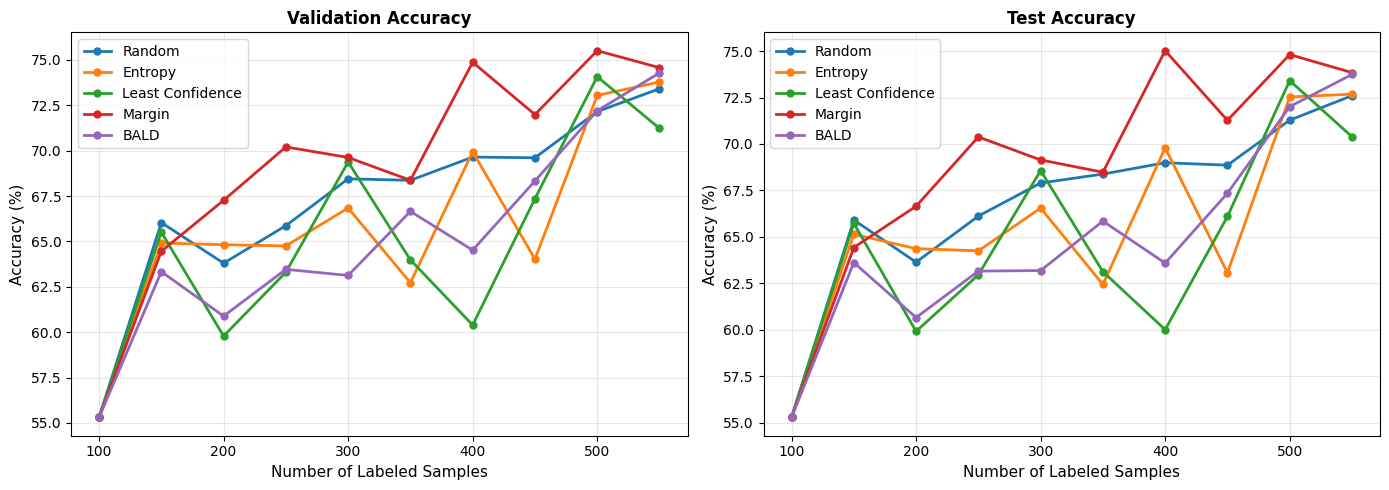

In [7]:
# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors

for i, (name, results) in enumerate(all_results.items()):
    color = colors[i]
    axes[0].plot(results["labeled_sizes"],
                 [a * 100 for a in results["val_accs"]],
                 marker='o', color=color, linewidth=2, markersize=5, label=name)
    axes[1].plot(results["labeled_sizes"],
                 [a * 100 for a in results["test_accs"]],
                 marker='o', color=color, linewidth=2, markersize=5, label=name)

for ax, title in zip(axes, ["Validation Accuracy", "Test Accuracy"], strict=False):
    ax.set_xlabel("Number of Labeled Samples", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Results summary table
print("\nFinal Results Summary:")
print("=" * 60)
print(f"{'Method':<20} {'Test Acc':>10} {'vs Random':>12}")
print("-" * 60)

random_acc = all_results["Random"]["test_accs"][-1]

# Sort by final test accuracy
sorted_results = sorted(all_results.items(),
                        key=lambda x: x[1]["test_accs"][-1],
                        reverse=True)

for name, results in sorted_results:
    final_acc = results["test_accs"][-1]
    improvement = (final_acc - random_acc) * 100
    marker = " <-- best" if final_acc == max(r["test_accs"][-1] for r in all_results.values()) else ""
    print(f"{name:<20} {final_acc*100:>9.2f}% {improvement:>+11.2f}%{marker}")

print("=" * 60)


Final Results Summary:
Method                 Test Acc    vs Random
------------------------------------------------------------
Margin                   73.84%       +1.24% <-- best
BALD                     73.74%       +1.14%
Entropy                  72.68%       +0.08%
Random                   72.60%       +0.00%
Least Confidence         70.39%       -2.21%


## Part 6: Advanced Strategies

Beyond simple uncertainty sampling, `incerto` provides more sophisticated strategies:

| Strategy | Key Idea | Best For |
|----------|----------|----------|
| `UncertaintySampling` | Select highest-scoring samples | Default choice |
| `DiversitySampling` | Balance uncertainty + diversity | Avoiding redundant samples |
| `CoreSetSelection` | Greedy k-center for coverage | Representative samples |
| `BadgeSampling` | Gradient embeddings + k-means++ | State-of-the-art |

Let's compare `DiversitySampling` against pure `UncertaintySampling`:

In [9]:
# Compare all 4 strategies
strategy_results = {}

strategies = {
    "Uncertainty (Entropy)": UncertaintySampling(EntropyAcquisition(), batch_size=n_query),
    "Diversity (Entropy, w=0.5)": DiversitySampling(EntropyAcquisition(), batch_size=n_query, diversity_weight=0.5),
    "CoreSet": CoreSetSelection(batch_size=n_query),
    "BADGE": BadgeSampling(batch_size=n_query),
}

for name, strategy in strategies.items():
    print(f"\nRunning: {name}")
    print("-" * 60)

    seed_everything(42)

    results = run_active_learning(
        strategy=strategy,
        initial_labeled=labeled_indices.copy(),
        initial_pool=pool_indices.copy(),
        n_rounds=n_rounds,
        n_query=n_query,
        train_epochs=train_epochs,
    )

    strategy_results[name] = results
    print(f"Final: {results['test_accs'][-1]*100:.1f}% test accuracy")


Running: Uncertainty (Entropy)
------------------------------------------------------------


  Round 1/10:  100 labels, val=55.3%, test=55.3%


  Round 2/10:  150 labels, val=64.9%, test=65.1%


  Round 3/10:  200 labels, val=64.8%, test=64.4%


  Round 4/10:  250 labels, val=64.8%, test=64.2%


...

  Round 7/10:  400 labels, val=73.7%, test=72.8%


  Round 8/10:  450 labels, val=68.2%, test=67.8%


  Round 9/10:  500 labels, val=73.7%, test=72.6%


  Round 10/10:  550 labels, val=76.6%, test=76.1%


Final: 76.1% test accuracy


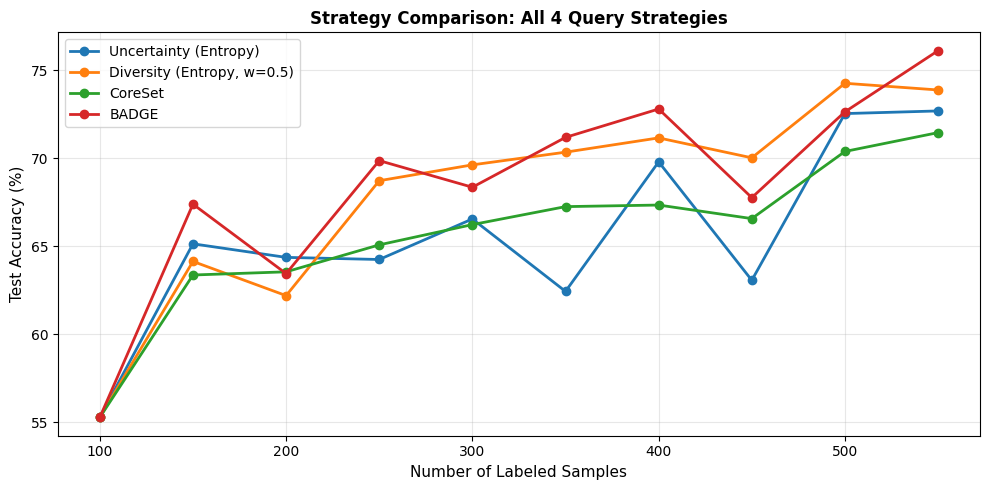


Strategy Comparison Summary:
Strategy                        Final Test Acc
------------------------------------------------------------
BADGE                                   76.10%
Diversity (Entropy, w=0.5)              73.87%
Uncertainty (Entropy)                   72.68%
CoreSet                                 71.45%


In [10]:
# Plot strategy comparison
plt.figure(figsize=(10, 5))

colors = plt.cm.tab10.colors
for i, (name, results) in enumerate(strategy_results.items()):
    plt.plot(results["labeled_sizes"],
             [a * 100 for a in results["test_accs"]],
             marker='o', color=colors[i], linewidth=2, markersize=6, label=name)

plt.xlabel("Number of Labeled Samples", fontsize=11)
plt.ylabel("Test Accuracy (%)", fontsize=11)
plt.title("Strategy Comparison: All 4 Query Strategies", fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\nStrategy Comparison Summary:")
print("=" * 60)
print(f"{'Strategy':<30} {'Final Test Acc':>15}")
print("-" * 60)
for name, results in sorted(strategy_results.items(),
                            key=lambda x: x[1]["test_accs"][-1],
                            reverse=True):
    print(f"{name:<30} {results['test_accs'][-1]*100:>14.2f}%")
print("=" * 60)

## Part 7: Using the Built-in Loop

`incerto` provides `active_learning_loop` for convenience:

In [11]:
from incerto.active import active_learning_loop

# Prepare data as tensors
x_pool = torch.stack([full_train[i][0] for i in pool_indices[:2000]]).to(device)
y_pool = torch.tensor([full_train[i][1] for i in pool_indices[:2000]]).to(device)

# Create strategy
strategy = UncertaintySampling(EntropyAcquisition(), batch_size=50)

# Define train/eval functions
def train_fn(model, x_train, y_train):
    """Quick training function."""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for _ in range(3):  # 3 epochs
        for i in range(0, len(x_train), 64):
            batch_x = x_train[i:i+64]
            batch_y = y_train[i:i+64]
            optimizer.zero_grad()
            loss = F.cross_entropy(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()

def eval_fn(model):
    """Evaluate on test set."""
    return evaluate(model, test_loader)

# Run the loop
model = ActiveNet().to(device)

results = active_learning_loop(
    model=model,
    x_pool=x_pool,
    y_pool=y_pool,
    strategy=strategy,
    num_rounds=5,
    initial_labeled=50,
    train_fn=train_fn,
    eval_fn=eval_fn,
    random_seed=42,
)

print(f"\nLabeled sizes: {results['labeled_sizes']}")
print(f"Accuracies: {[f'{a:.1%}' for a in results['accuracies']]}")


Labeled sizes: [50, 100, 150, 200, 250]
Accuracies: ['29.7%', '40.4%', '51.9%', '62.3%', '62.8%']


## Part 8: Best Practices

### Acquisition Function Selection

| Situation | Recommended |
|-----------|-------------|
| Default / quick start | `EntropyAcquisition` or `LeastConfidenceAcquisition` |
| Multi-class with many classes | `EntropyAcquisition` |
| Binary or few classes | `MarginAcquisition` |
| Model with dropout | `BALDAcquisition` (requires MC sampling) |
| Need diversity | `DiversitySampling` with any acquisition |
| State-of-the-art | `BadgeSampling` |

### Key Recommendations

1. **Start with Entropy or Least Confidence** - simple and effective
2. **Use 50-100 samples per query round** - balances annotation cost vs model improvement
3. **Add diversity** when seeing diminishing returns - `DiversitySampling` with `diversity_weight=0.3-0.5`
4. **For Bayesian methods (BALD)** - ensure model has dropout and use `model.train()` during scoring
5. **Compare against random baseline** - to verify active learning is helping
6. **Use held-out test set** - don't query from test set!

### Common Pitfalls

| Pitfall | Solution |
|---------|----------|
| Querying outliers/noise | Use `DiversitySampling` or `MarginAcquisition` |
| Class imbalance worsening | Use stratified querying |
| Cold start (poor initial queries) | Start with random or pretrained features |
| Redundant queries | Use `DiversitySampling` or `CoreSetSelection` |

### Integration with Other Methods

```python
# Active Learning + Calibration (calibrate before querying)
from incerto.calibration import TemperatureScaling

calibrator = TemperatureScaling()
calibrator.fit(val_logits, val_labels)
# Use calibrated probabilities for acquisition

# Active Learning + Bayesian Methods
from incerto.bayesian import MCDropout
from incerto.active import BALDAcquisition

# BALD works best with MC Dropout for uncertainty
acq = BALDAcquisition(num_samples=20)
```

## Summary

In this notebook, you learned:

1. **Active Learning Fundamentals** - query strategies reduce labeling costs
2. **8 Acquisition Functions** - Random, Entropy, Least Confidence, Margin, BALD, Variance Ratio, Mean STD, BatchBALD
3. **4 Query Strategies** - UncertaintySampling, DiversitySampling, CoreSetSelection, BadgeSampling
4. **Active Learning Loop** - train, score, query, repeat
5. **Method Comparison** - Entropy/Margin often best, BALD for Bayesian models
6. **Best Practices** - start simple, add diversity, compare to random

**Key Takeaways:**
- Active learning can reduce annotation costs by 30-70%
- `EntropyAcquisition` + `UncertaintySampling` is a strong default
- Add `DiversitySampling` when seeing redundant queries
- Always compare against random baseline